# Phase-Space Reconstruction — Session 1

This notebook validates `reconstruct_phase_space` from `psr.py` on
`sample_1.csv`. SQI-valid and Processed-stationary windows are loaded
directly through `get_data` from `loader.py`.

The experiment uses fixed parameters throughout:

- embedding dimension: `d = 4`;
- time lag: `m = 9` samples.

In the core API, these map to `m=d` and `tau=m`. Exactly one Awake
window and one Drowsy window are selected for each duration
(`60/120/180 s`). All scenarios reuse these six windows.

In [1]:
import sys
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start):
    """Find the repository root."""
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Repository root was not found.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
repo_path = str(REPO_ROOT)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

loader = import_module("phase1.src.dataloader.loader")
psr = import_module("phase1.src.embedding.psr")
get_data = loader.get_data
reconstruct_phase_space = psr.reconstruct_phase_space

SESSION = "sample_1.csv"
DATA_DIR = REPO_ROOT / "phase1" / "segmentated_data" / "dhdata"
WINDOW_SIZES = (60, 120, 180)
STATE_NAMES = {0: "Awake", 1: "Drowsy"}
COLORS = {0: "#0072B2", 1: "#D55E00"}
D = 4
M = 9

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 0.7,
})

## Session test and window selection

`get_data` returns separate Awake and Drowsy batches containing aligned
Raw, Processed, and reconstructed Time matrices. The first window from
each state and duration is selected; no other window is used later.

In [2]:
data_awake, data_drowsy = get_data(
    SESSION,
    data_dir=DATA_DIR,
    window_sizes=WINDOW_SIZES,
    stationarity="processed",
)
state_data = {0: data_awake, 1: data_drowsy}


def select_window(window_size, label):
    """Select the first window from one state batch."""
    batch = state_data[label][window_size]
    if batch["processed"].shape[0] == 0:
        state = STATE_NAMES[label]
        raise ValueError(f"No {window_size} s window for {state}.")

    selected = {
        "raw": batch["raw"][0].copy(),
        "processed": batch["processed"][0].copy(),
        "time": batch["time"][0].copy(),
        "metadata": {
            "window_id": int(batch["window_id"][0]),
            "start_time": float(batch["start_time"][0]),
            "end_time": float(batch["end_time"][0]),
            "fs": float(batch["fs"]),
        },
    }

    assert selected["raw"].shape == selected["processed"].shape
    assert selected["raw"].shape == selected["time"].shape
    assert np.all(np.diff(selected["time"]) > 0)
    return selected


selected_windows = {
    (size, label): select_window(size, label)
    for size in WINDOW_SIZES
    for label in STATE_NAMES
}

selection_records = []
for (size, label), selected in selected_windows.items():
    details = selected["metadata"]
    selection_records.append({
        "window_size_s": size,
        "state": STATE_NAMES[label],
        "window_id": details["window_id"],
        "start_time": details["start_time"],
        "end_time": details["end_time"],
        "n_samples": len(selected["processed"]),
    })

selection_table = pd.DataFrame(selection_records)
counts = selection_table.groupby("window_size_s").size()
assert len(selected_windows) == 2 * len(WINDOW_SIZES)
assert counts.eq(2).all()
display(selection_table)
print(f"Sampling rate: {data_awake[60]['fs']:.2f} Hz")

,window_size_s,state,window_id,start_time,end_time,n_samples
0,60,Awake,1,2.63,62.61,3000
1,60,Drowsy,18,1117.37,1177.35,3000
2,120,Awake,1,2.63,122.61,6000
3,120,Drowsy,11,1535.85,1655.83,6000
4,180,Awake,1,2.63,182.61,9000
5,180,Drowsy,6,1535.85,1715.83,9000


Sampling rate: 50.00 Hz


In [3]:
def reconstruct(signal):
    """Reconstruct with the fixed experimental parameters."""
    return reconstruct_phase_space(signal, m=D, tau=M)


def expected_shape(signal):
    """Return the expected fixed-parameter output shape."""
    return (len(signal) - (D - 1) * M, D)


def plot_projection_2d(phase, ax, title, color):
    """Plot the first two coordinates of a 4D embedding."""
    ax.plot(
        phase[:, 0],
        phase[:, 1],
        color=color,
        alpha=0.75,
    )
    ax.set(
        title=title,
        xlabel=r"$x(t)$",
        ylabel=rf"$x(t + {M}\,\Delta t)$",
    )
    ax.set_box_aspect(1)

## 1. Basic integrity

Validate phase-space shape, finite values, and Raw/Processed/Time
alignment for all six windows returned through `get_data`.

In [4]:
processed_phases = {}
integrity_records = []

for key, selected in selected_windows.items():
    size, label = key
    signal = selected["processed"]
    phase = reconstruct(signal)
    expected = expected_shape(signal)
    aligned = (
        selected["raw"].shape
        == selected["processed"].shape
        == selected["time"].shape
    )

    assert phase.shape == expected
    assert np.isfinite(phase).all()
    assert aligned
    processed_phases[key] = phase
    integrity_records.append({
        "window_size_s": size,
        "state": STATE_NAMES[label],
        "expected_shape": expected,
        "actual_shape": phase.shape,
        "data_aligned": aligned,
        "all_finite": np.isfinite(phase).all(),
    })

integrity_table = pd.DataFrame(integrity_records)
display(integrity_table)

,window_size_s,state,expected_shape,actual_shape,data_aligned,all_finite
0,60,Awake,"(2973, 4)","(2973, 4)",True,True
1,60,Drowsy,"(2973, 4)","(2973, 4)",True,True
2,120,Awake,"(5973, 4)","(5973, 4)",True,True
3,120,Drowsy,"(5973, 4)","(5973, 4)",True,True
4,180,Awake,"(8973, 4)","(8973, 4)",True,True
5,180,Drowsy,"(8973, 4)","(8973, 4)",True,True


## 2. Window-size comparison

Compare `60/120/180 s` separately for Awake and Drowsy. Each panel is
a 2D projection of the same fixed 4D reconstruction.

<>:15: SyntaxWarning: invalid escape sequence '\,'
<>:15: SyntaxWarning: invalid escape sequence '\,'
C:\Users\Admin\AppData\Local\Temp\ipykernel_31140\335552887.py:15: SyntaxWarning: invalid escape sequence '\,'
  f"{STATE_NAMES[label]}\n$x(t + {M}\,\Delta t)$"


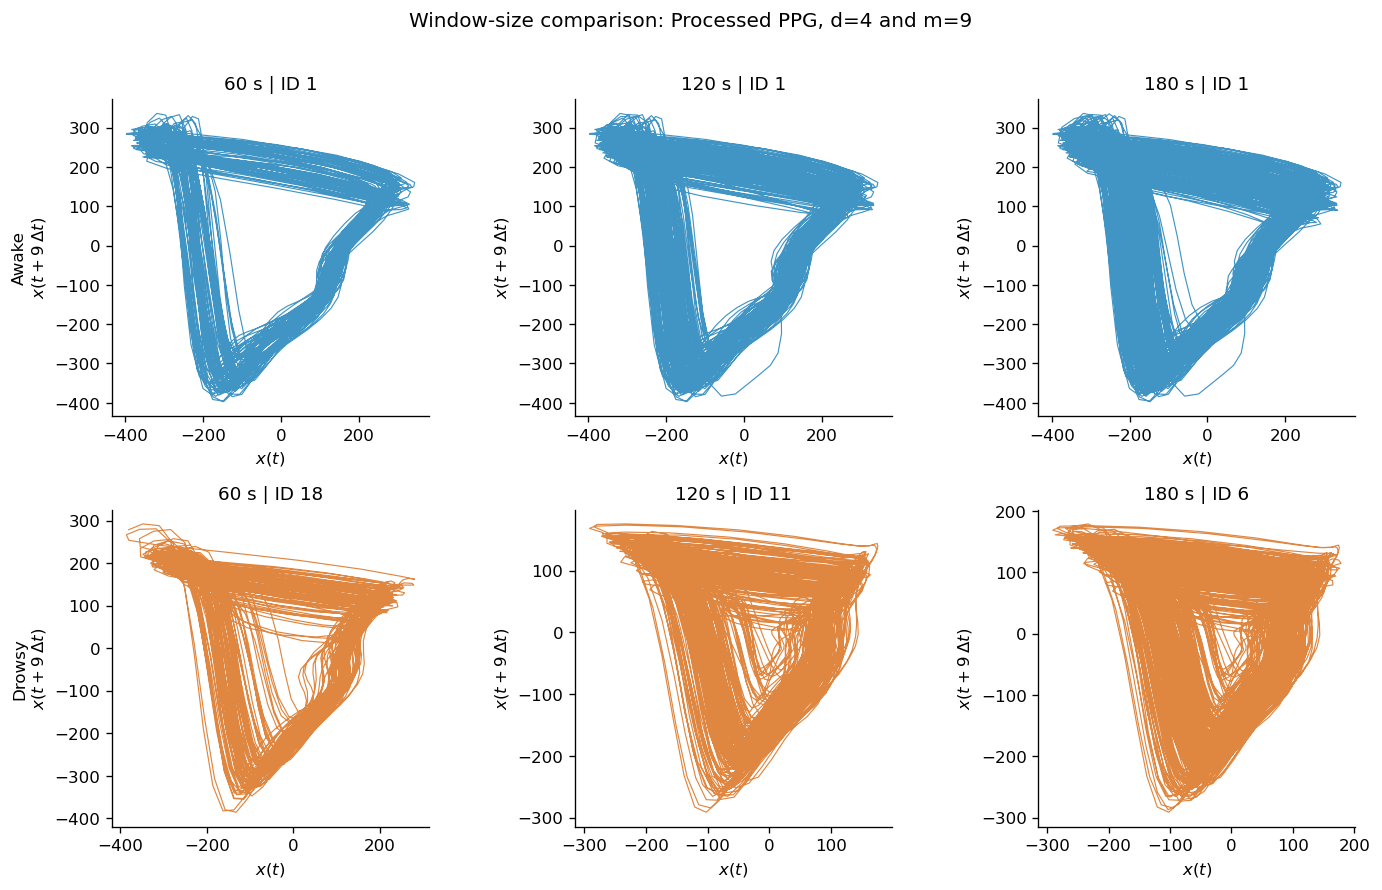

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.3))

for row_index, label in enumerate(STATE_NAMES):
    for column_index, size in enumerate(WINDOW_SIZES):
        selected = selected_windows[(size, label)]
        row = selected["metadata"]
        title = f"{size} s | ID {int(row['window_id'])}"
        plot_projection_2d(
            processed_phases[(size, label)],
            axes[row_index, column_index],
            title,
            COLORS[label],
        )
    axes[row_index, 0].set_ylabel(
        f"{STATE_NAMES[label]}\n$x(t + {M}\,\Delta t)$"
    )

fig.suptitle(
    "Window-size comparison: Processed PPG, d=4 and m=9",
    y=1.01,
)
fig.tight_layout()
plt.show()

## 3. Awake vs Drowsy

Compare the selected Awake and Drowsy windows at the same duration.
The 120 s pair is reused from the six-window selection.

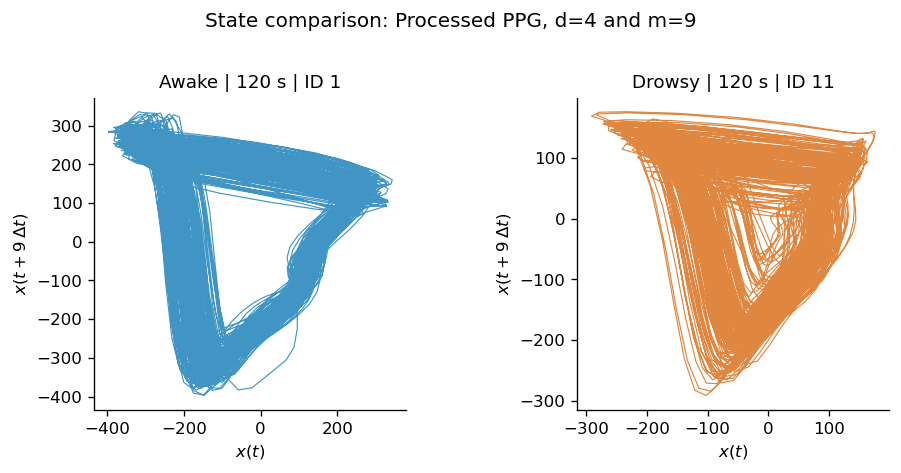

In [6]:
comparison_size = 120
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))

for ax, label in zip(axes, STATE_NAMES):
    selected = selected_windows[(comparison_size, label)]
    row = selected["metadata"]
    title = (
        f"{STATE_NAMES[label]} | {comparison_size} s | "
        f"ID {int(row['window_id'])}"
    )
    plot_projection_2d(
        processed_phases[(comparison_size, label)],
        ax,
        title,
        COLORS[label],
    )

fig.suptitle("State comparison: Processed PPG, d=4 and m=9", y=1.02)
fig.tight_layout()
plt.show()

## 4. Raw vs Processed

Reconstruct both representations for the same selected 120 s Awake
and Drowsy windows. Original amplitudes are retained.

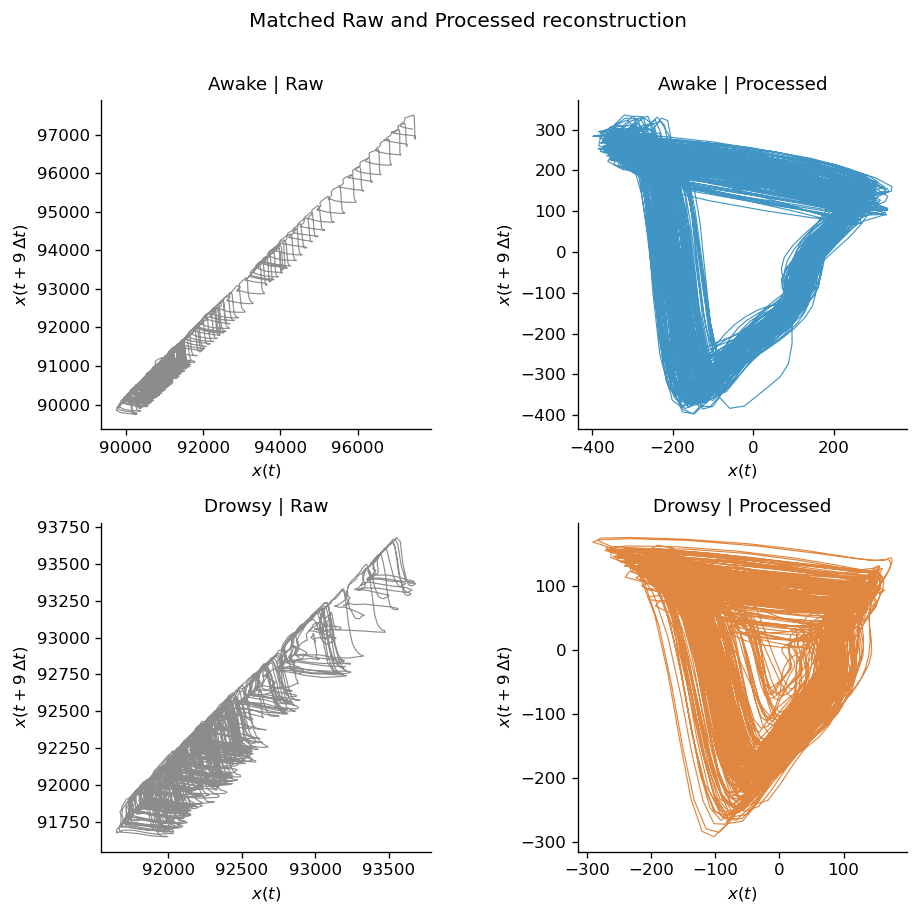

,state,window_id,raw_shape,processed_shape,aligned
0,Awake,1,"(5973, 4)","(5973, 4)",True
1,Drowsy,11,"(5973, 4)","(5973, 4)",True


In [7]:
representation_phases = {}
alignment_records = []

for label in STATE_NAMES:
    selected = selected_windows[(comparison_size, label)]
    raw_phase = reconstruct(selected["raw"])
    processed_phase = processed_phases[(comparison_size, label)]

    assert raw_phase.shape == processed_phase.shape
    representation_phases[(label, "raw")] = raw_phase
    representation_phases[(label, "processed")] = processed_phase
    alignment_records.append({
        "state": STATE_NAMES[label],
        "window_id": int(selected["metadata"]["window_id"]),
        "raw_shape": raw_phase.shape,
        "processed_shape": processed_phase.shape,
        "aligned": raw_phase.shape == processed_phase.shape,
    })

fig, axes = plt.subplots(2, 2, figsize=(8.3, 7.5))
for row_index, label in enumerate(STATE_NAMES):
    for column_index, representation in enumerate(
        ("raw", "processed")
    ):
        title = f"{STATE_NAMES[label]} | {representation.title()}"
        color = "#666666" if representation == "raw" else COLORS[label]
        plot_projection_2d(
            representation_phases[(label, representation)],
            axes[row_index, column_index],
            title,
            color,
        )

fig.suptitle("Matched Raw and Processed reconstruction", y=1.01)
fig.tight_layout()
plt.show()
alignment_table = pd.DataFrame(alignment_records)
display(alignment_table)

## 5. Native 3D visualization

The existing 2D projections are retained. For the selected 120 s Awake
window, `plot=True` is passed directly to `reconstruct_phase_space` with
fixed `d=4` and `m=9`. The native plot shows the first three coordinates
of the returned 4D phase space.

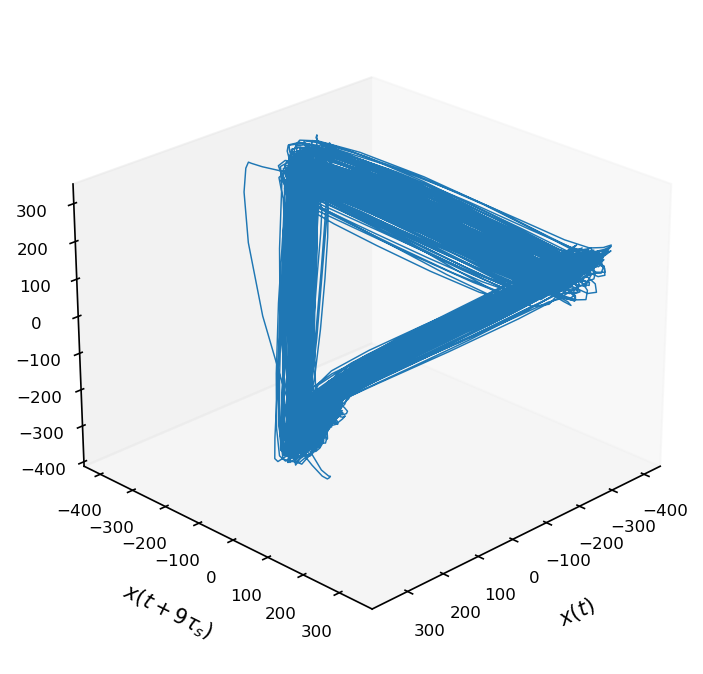

Native 3D plot completed from fixed 4D phase space: (5973, 4)


In [8]:
reference_window = selected_windows[(comparison_size, 0)]
reference_signal = reference_window["processed"]
reference_phase = processed_phases[(comparison_size, 0)]

native_phase = reconstruct_phase_space(
    reference_signal,
    m=D,
    tau=M,
    plot=True,
)

assert np.array_equal(native_phase, reference_phase)
print(
    "Native 3D plot completed from fixed 4D phase space:",
    native_phase.shape,
)

## 6. Edge cases

Invalid inputs must fail with a clear exception type and message.

In [9]:
def capture_error(name, function, expected_type):
    """Run an invalid case and capture its expected error."""
    try:
        function()
    except expected_type as error:
        return {
            "case": name,
            "status": "PASS",
            "exception": type(error).__name__,
            "message": str(error),
        }
    except Exception as error:
        raise AssertionError(
            f"{name} raised {type(error).__name__}, "
            f"expected {expected_type.__name__}."
        ) from error
    raise AssertionError(f"{name} did not raise an exception.")


edge_cases = [
    (
        "2D signal",
        lambda: reconstruct_phase_space(np.ones((8, 2)), D, M),
        ValueError,
    ),
    (
        "NaN",
        lambda: reconstruct_phase_space(
            np.array([1.0, np.nan, 2.0]),
            D,
            M,
        ),
        ValueError,
    ),
    (
        "Inf",
        lambda: reconstruct_phase_space(
            np.array([1.0, np.inf, 2.0]),
            D,
            M,
        ),
        ValueError,
    ),
    (
        "Embedding dimension < 2",
        lambda: reconstruct_phase_space(np.arange(20), 1, M),
        ValueError,
    ),
    (
        "Time lag < 1",
        lambda: reconstruct_phase_space(np.arange(20), D, 0),
        ValueError,
    ),
    (
        "Signal too short",
        lambda: reconstruct_phase_space(np.arange(20), D, M),
        ValueError,
    ),
]

edge_results = [
    capture_error(name, function, expected_type)
    for name, function, expected_type in edge_cases
]
edge_table = pd.DataFrame(edge_results)
assert edge_table["status"].eq("PASS").all()
display(edge_table)

,case,status,exception,message
0,2D signal,PASS,ValueError,signal must be a 1D array.
1,NaN,PASS,ValueError,signal must contain only finite values.
2,Inf,PASS,ValueError,signal must contain only finite values.
3,Embedding dimension < 2,PASS,ValueError,m must be at least 2.
4,Time lag < 1,PASS,ValueError,tau must be at least 1.
5,Signal too short,PASS,ValueError,signal is too short for the requested m and tau.


## Ready-to-freeze summary

This cell consolidates the executable acceptance checks.

In [10]:
fixed_shapes = all(
    record["expected_shape"] == record["actual_shape"]
    for record in integrity_records
)
data_aligned = all(
    record["data_aligned"]
    for record in integrity_records
)
freeze_checks = {
    "get_data used for session 1": SESSION == "sample_1.csv",
    "Fixed d=4 and m=9 used throughout": fixed_shapes,
    "Exactly two windows selected per size": counts.eq(2).all(),
    "Raw/Processed/Time alignment preserved": data_aligned,
    "Raw/Processed phase alignment preserved": alignment_table[
        "aligned"
    ].all(),
    "Awake and Drowsy reconstructed": (
        {key[1] for key in processed_phases} == {0, 1}
    ),
    "60/120/180 s reconstructed": (
        {key[0] for key in processed_phases} == set(WINDOW_SIZES)
    ),
    "2D projections completed": bool(processed_phases),
    "Native 3D plot=True completed": np.array_equal(
        native_phase,
        reference_phase,
    ),
    "All edge cases failed clearly": edge_table["status"].eq(
        "PASS"
    ).all(),
}

assert all(freeze_checks.values())
freeze_table = pd.DataFrame({
    "criterion": freeze_checks.keys(),
    "status": [
        "PASS" if passed else "FAIL"
        for passed in freeze_checks.values()
    ],
})
display(freeze_table)
print("Core PSR is ready to freeze for fixed d=4 and m=9.")

,criterion,status
0,get_data used for session 1,PASS
1,Fixed d=4 and m=9 used throughout,PASS
2,Exactly two windows selected per size,PASS
3,Raw/Processed/Time alignment preserved,PASS
4,Raw/Processed phase alignment preserved,PASS
5,Awake and Drowsy reconstructed,PASS
6,60/120/180 s reconstructed,PASS
7,2D projections completed,PASS
8,Native 3D plot=True completed,PASS
9,All edge cases failed clearly,PASS


Core PSR is ready to freeze for fixed d=4 and m=9.


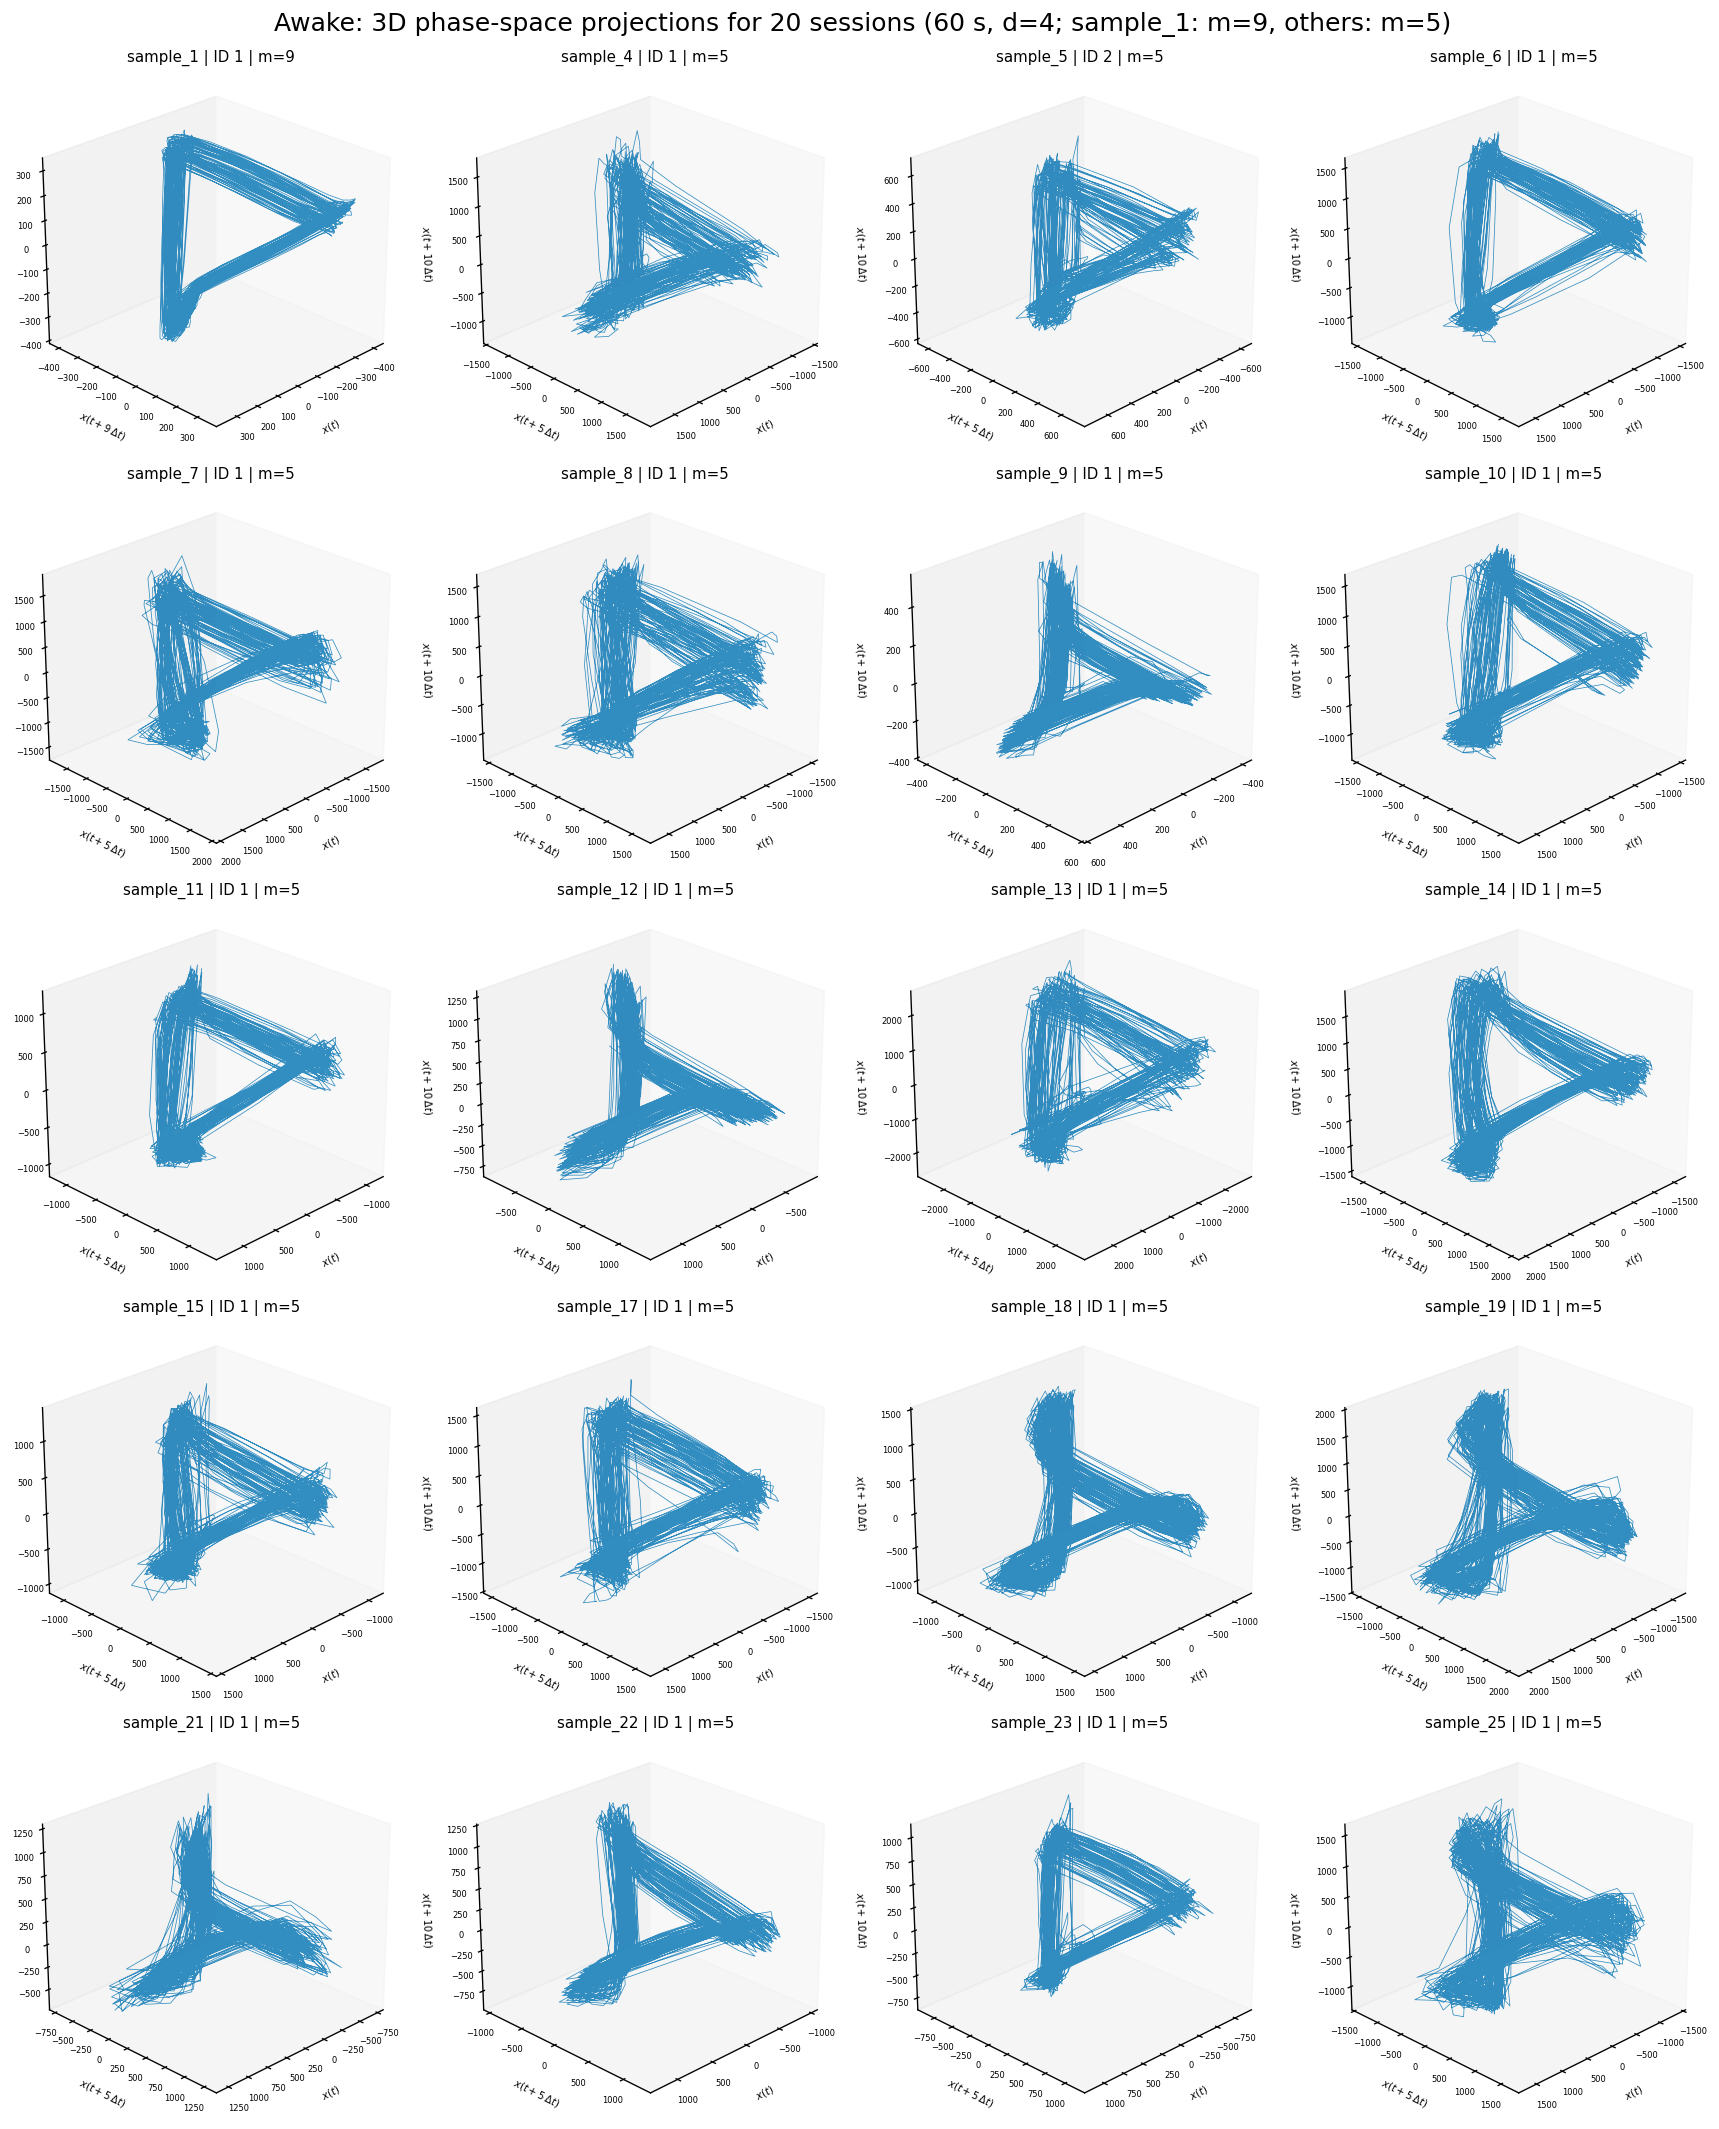

Logged 20 Awake 3D plots for 60 s windows (sample_1: m=9; others: m=5).


In [11]:
session_names = tuple(
    path.stem
    for path in sorted(
        DATA_DIR.glob("sample_*.npz"),
        key=lambda path: int(path.stem.rsplit("_", 1)[1]),
    )
)
assert len(session_names) == 20

session_lags = {
    session_name: 9 if session_name == "sample_1" else 5
    for session_name in session_names
}
assert session_lags["sample_1"] == 9
assert all(
    lag == 5
    for session_name, lag in session_lags.items()
    if session_name != "sample_1"
)

session_phases = {0: {}, 1: {}}
session_window_ids = {0: {}, 1: {}}

for session_name in session_names:
    session_awake, session_drowsy = get_data(
        session_name,
        data_dir=DATA_DIR,
        window_sizes=60,
        stationarity="processed",
    )
    session_states = {0: session_awake, 1: session_drowsy}
    session_lag = session_lags[session_name]

    for label, state_batches in session_states.items():
        batch = state_batches[60]
        if batch["processed"].shape[0] == 0:
            state = STATE_NAMES[label]
            raise ValueError(
                f"No valid 60 s {state} window for {session_name}."
            )

        signal = batch["processed"][0]
        session_phases[label][session_name] = (
            reconstruct_phase_space(
                signal,
                m=D,
                tau=session_lag,
            )
        )
        session_window_ids[label][session_name] = int(
            batch["window_id"][0]
        )


def plot_3d_session_grid(label):
    """Plot one 5x4 state grid for all sessions."""
    state = STATE_NAMES[label]
    fig = plt.figure(figsize=(15, 18))

    for index, session_name in enumerate(session_names, start=1):
        ax = fig.add_subplot(5, 4, index, projection="3d")
        phase = session_phases[label][session_name]
        window_id = session_window_ids[label][session_name]
        session_lag = session_lags[session_name]

        ax.plot(
            phase[:, 0],
            phase[:, 1],
            phase[:, 2],
            color=COLORS[label],
            linewidth=0.45,
            alpha=0.8,
        )
        ax.set_title(
            f"{session_name} | ID {window_id} | m={session_lag}",
            fontsize=9,
            pad=2,
        )
        ax.set_xlabel(r"$x(t)$", fontsize=6, labelpad=-2)
        ax.set_ylabel(
            rf"$x(t + {session_lag}\,\Delta t)$",
            fontsize=6,
            labelpad=-2,
        )
        ax.set_zlabel(
            rf"$x(t + {2 * session_lag}\,\Delta t)$",
            fontsize=6,
            labelpad=-2,
        )
        ax.tick_params(labelsize=5, pad=-1)
        ax.view_init(elev=25, azim=45)
        ax.set_box_aspect((1, 1, 0.85))
        ax.grid(False)

    fig.suptitle(
        f"{state}: 3D phase-space projections for 20 sessions "
        f"(60 s, d={D}; sample_1: m=9, others: m=5)",
        fontsize=15,
        y=0.995,
    )
    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.02,
        top=0.97,
        wspace=0.02,
        hspace=0.08,
    )
    plt.show()
    return fig


awake_3d_figure = plot_3d_session_grid(label=0)
assert len(session_phases[0]) == 20
print(
    "Logged 20 Awake 3D plots for 60 s windows "
    "(sample_1: m=9; others: m=5)."
)

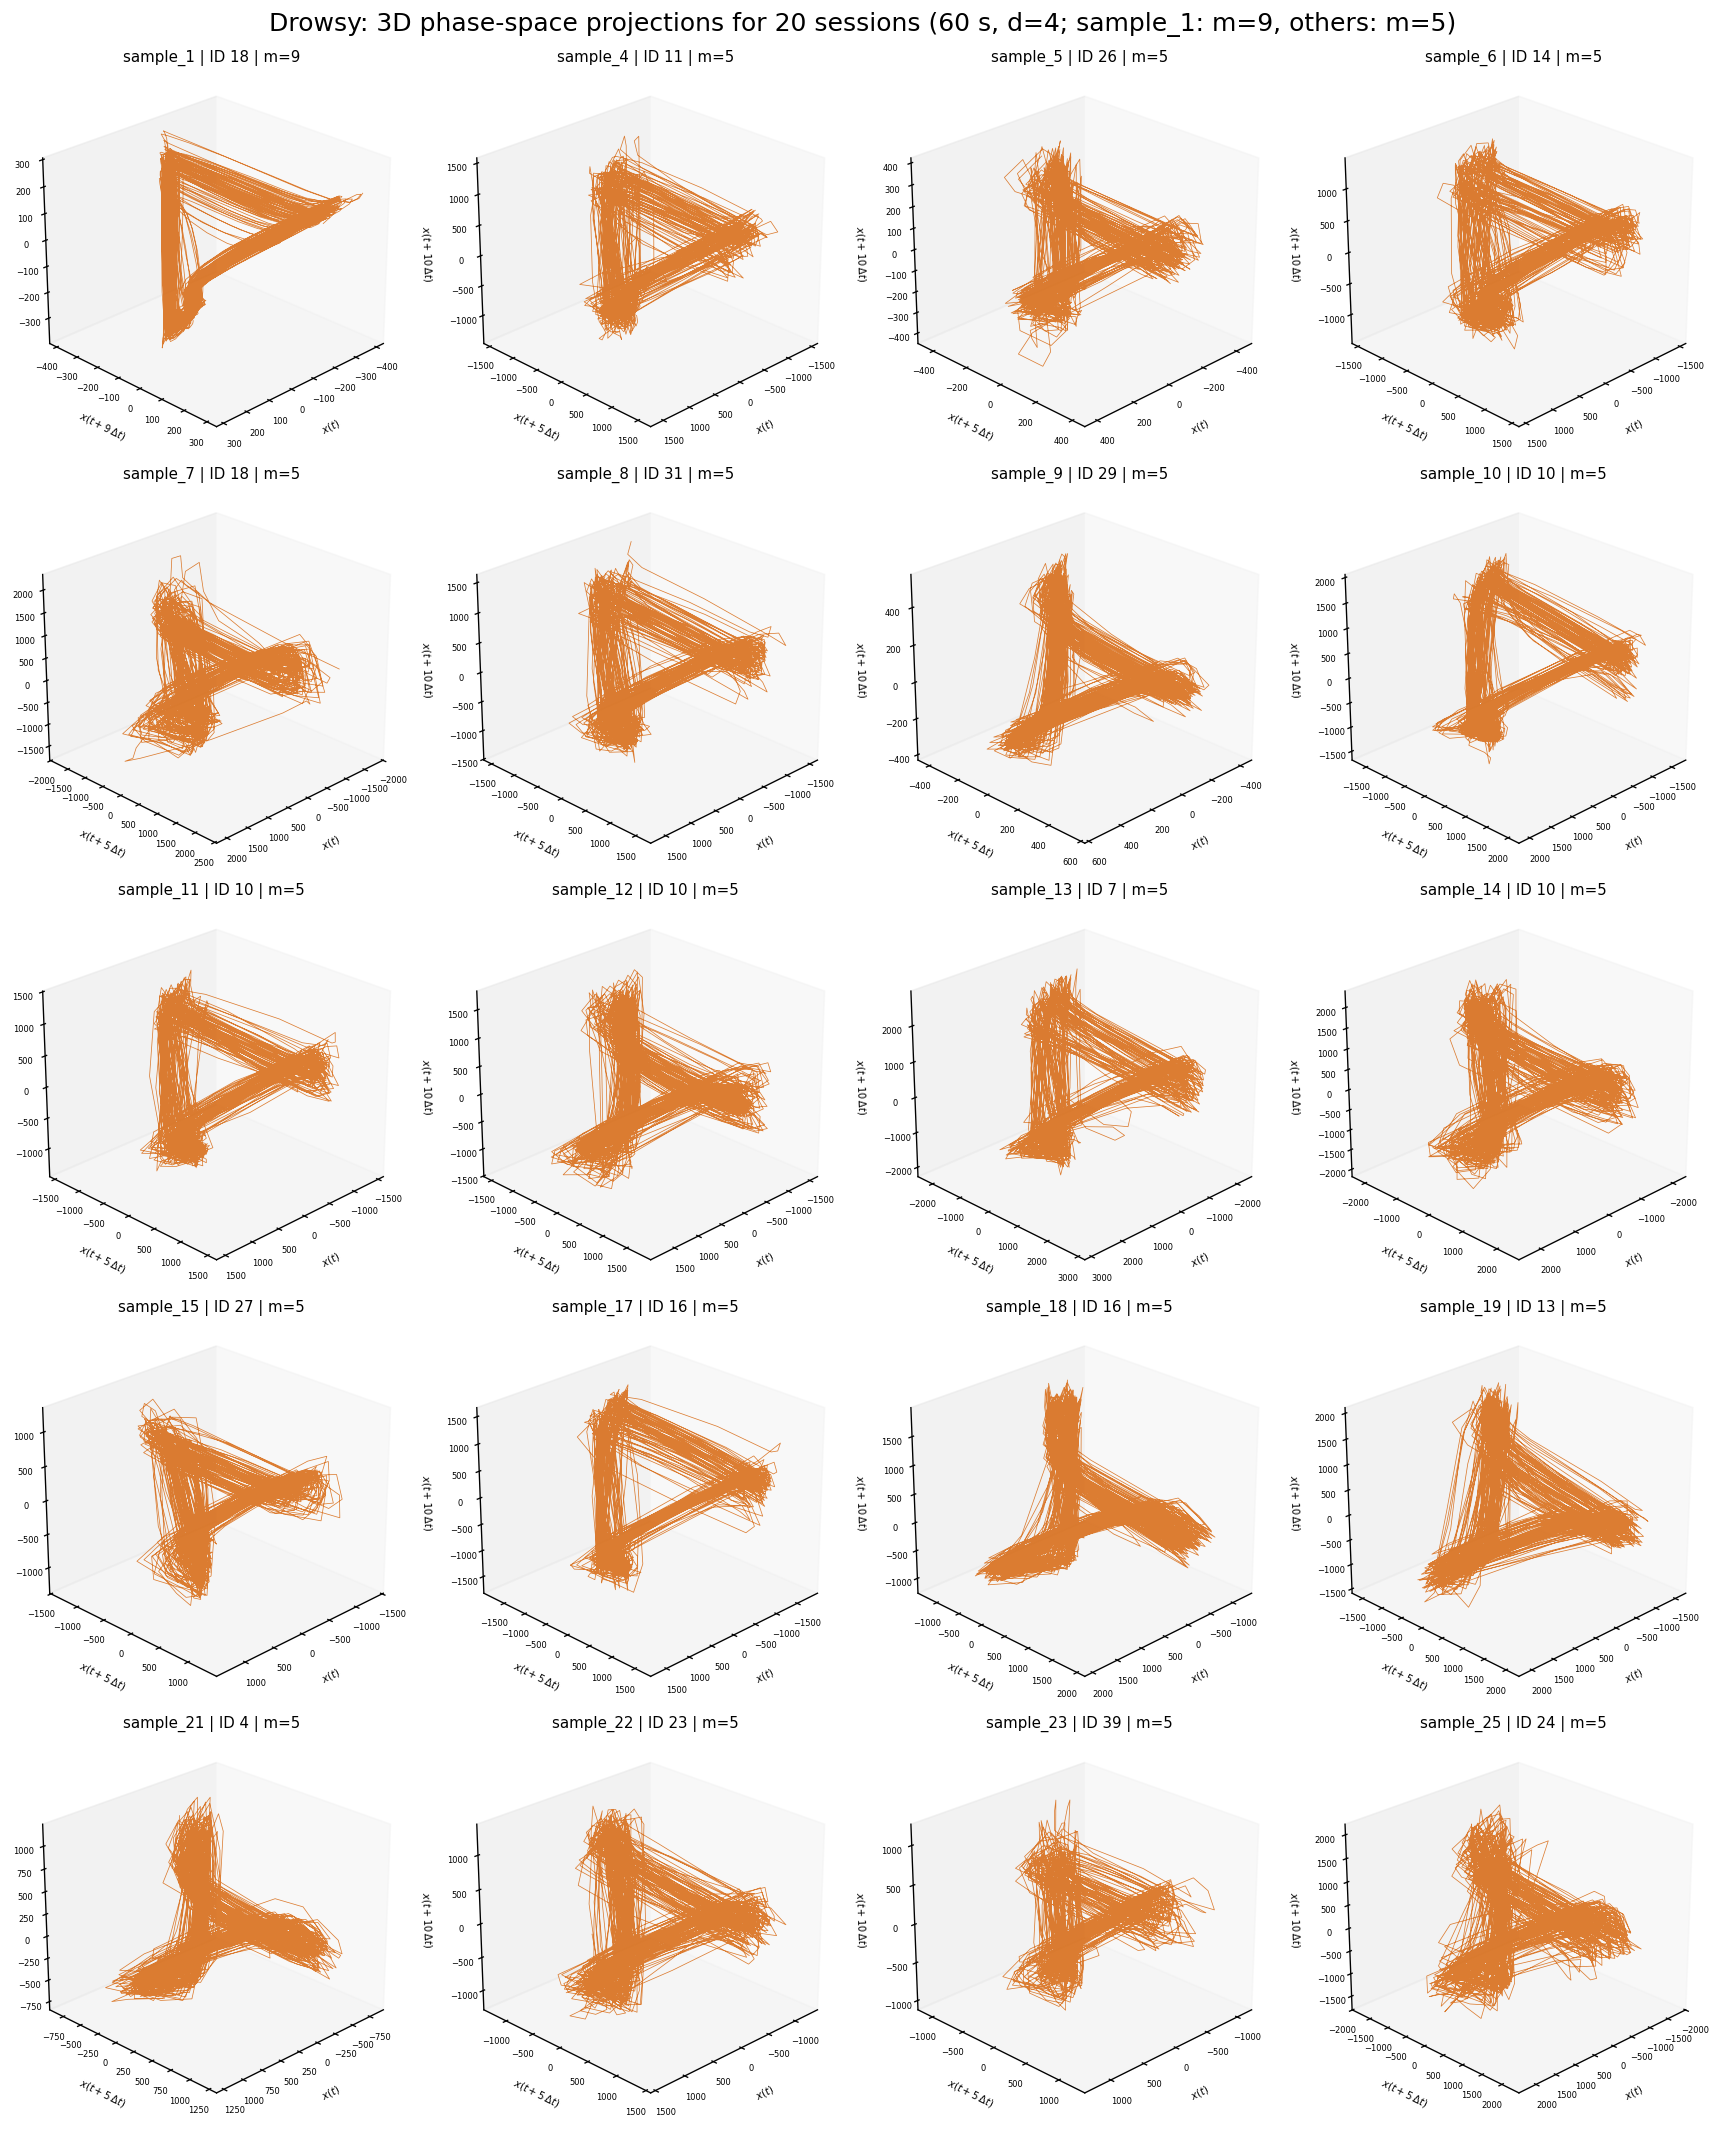

Logged 20 Drowsy 3D plots for 60 s windows (sample_1: m=9; others: m=5).


In [12]:
drowsy_3d_figure = plot_3d_session_grid(label=1)
assert len(session_phases[1]) == 20
print(
    "Logged 20 Drowsy 3D plots for 60 s windows "
    "(sample_1: m=9; others: m=5)."
)

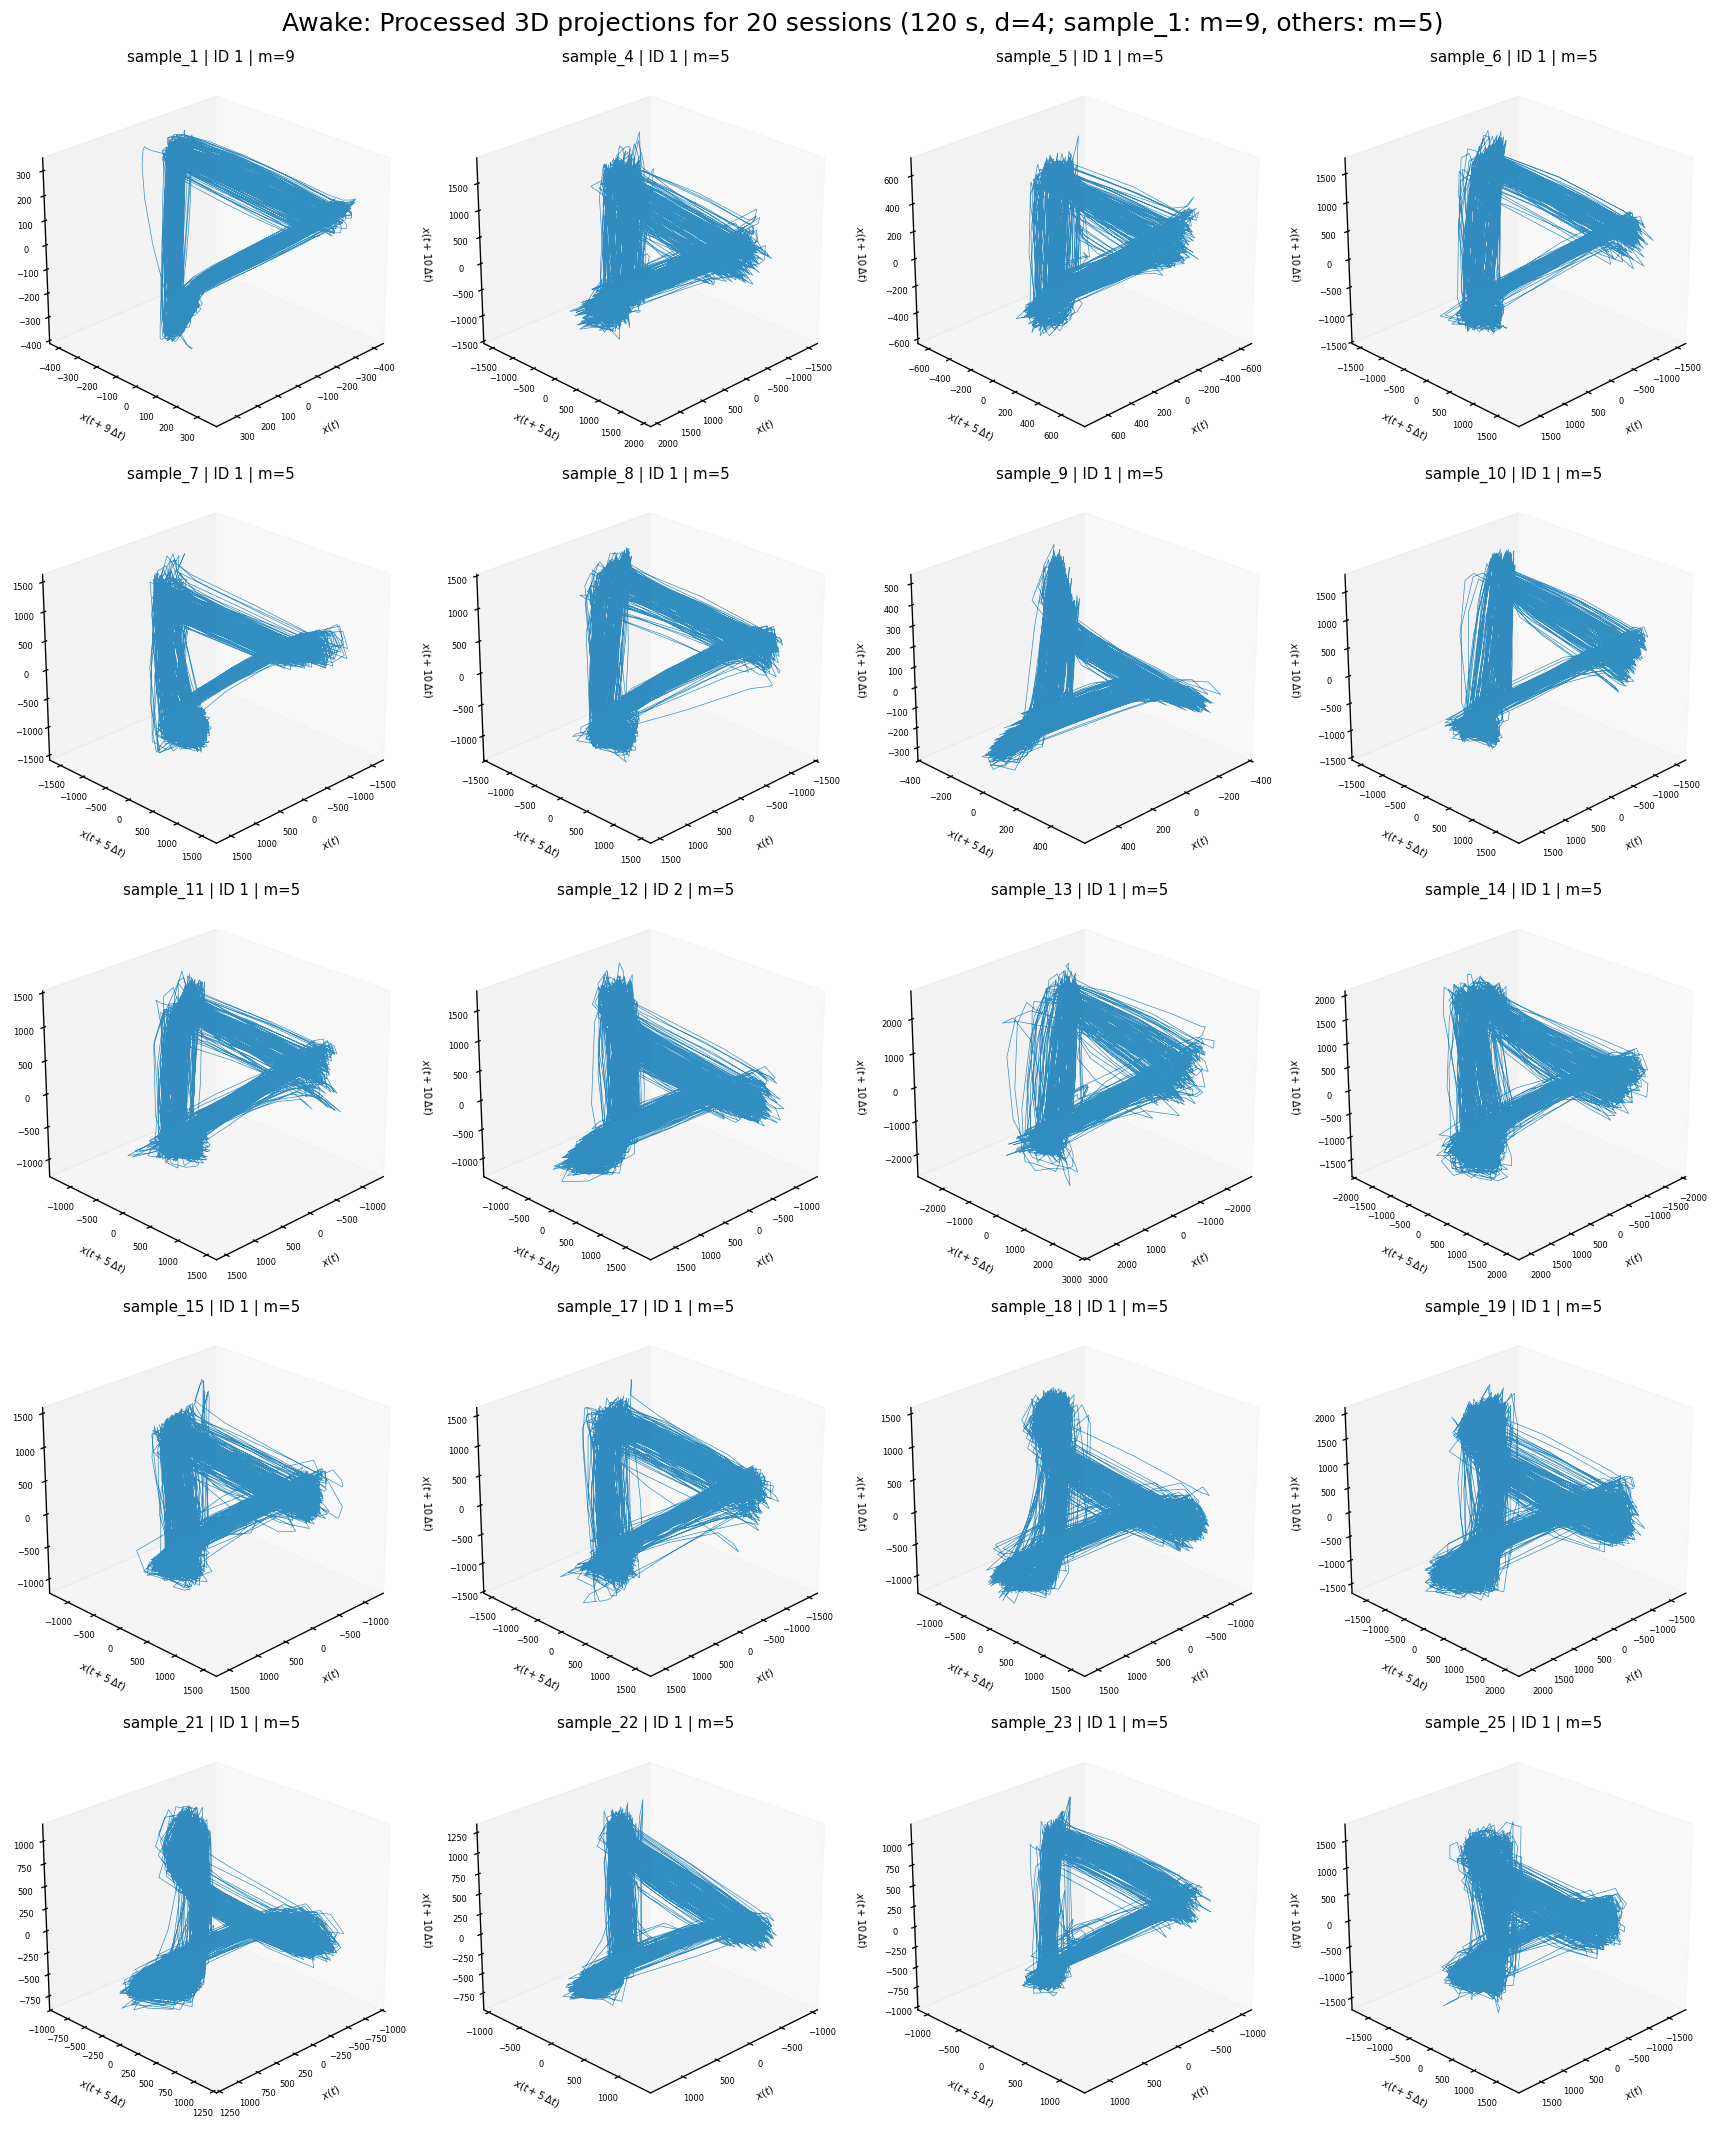

Logged 20 Awake Processed 3D plots for 120 s windows (sample_1: m=9; others: m=5).


In [13]:
def load_processed_session_phases(window_size):
    """Load one Processed phase space per state and session."""
    phases = {0: {}, 1: {}}
    window_ids = {0: {}, 1: {}}

    for session_name in session_names:
        session_awake, session_drowsy = get_data(
            session_name,
            data_dir=DATA_DIR,
            window_sizes=window_size,
            stationarity="processed",
        )
        session_states = {0: session_awake, 1: session_drowsy}
        session_lag = session_lags[session_name]

        for label, state_batches in session_states.items():
            batch = state_batches[window_size]
            if batch["processed"].shape[0] == 0:
                state = STATE_NAMES[label]
                raise ValueError(
                    f"No valid {window_size} s {state} window "
                    f"for {session_name}."
                )

            phases[label][session_name] = (
                reconstruct_phase_space(
                    batch["processed"][0],
                    m=D,
                    tau=session_lag,
                )
            )
            window_ids[label][session_name] = int(
                batch["window_id"][0]
            )

    return phases, window_ids


def plot_processed_3d_grid(
    phases,
    window_ids,
    label,
    window_size,
):
    """Plot one 5x4 Processed-data grid."""
    state = STATE_NAMES[label]
    fig = plt.figure(figsize=(15, 18))

    for index, session_name in enumerate(session_names, start=1):
        ax = fig.add_subplot(5, 4, index, projection="3d")
        phase = phases[label][session_name]
        window_id = window_ids[label][session_name]
        session_lag = session_lags[session_name]

        ax.plot(
            phase[:, 0],
            phase[:, 1],
            phase[:, 2],
            color=COLORS[label],
            linewidth=0.4,
            alpha=0.8,
        )
        ax.set_title(
            f"{session_name} | ID {window_id} | m={session_lag}",
            fontsize=9,
            pad=2,
        )
        ax.set_xlabel(r"$x(t)$", fontsize=6, labelpad=-2)
        ax.set_ylabel(
            rf"$x(t + {session_lag}\,\Delta t)$",
            fontsize=6,
            labelpad=-2,
        )
        ax.set_zlabel(
            rf"$x(t + {2 * session_lag}\,\Delta t)$",
            fontsize=6,
            labelpad=-2,
        )
        ax.tick_params(labelsize=5, pad=-1)
        ax.view_init(elev=25, azim=45)
        ax.set_box_aspect((1, 1, 0.85))
        ax.grid(False)

    fig.suptitle(
        f"{state}: Processed 3D projections for 20 sessions "
        f"({window_size} s, d={D}; sample_1: m=9, others: m=5)",
        fontsize=15,
        y=0.995,
    )
    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.02,
        top=0.97,
        wspace=0.02,
        hspace=0.08,
    )
    plt.show()
    return fig


session_phases_120, session_window_ids_120 = (
    load_processed_session_phases(120)
)
awake_120_3d_figure = plot_processed_3d_grid(
    session_phases_120,
    session_window_ids_120,
    label=0,
    window_size=120,
)
assert len(session_phases_120[0]) == 20
print(
    "Logged 20 Awake Processed 3D plots for 120 s windows "
    "(sample_1: m=9; others: m=5)."
)

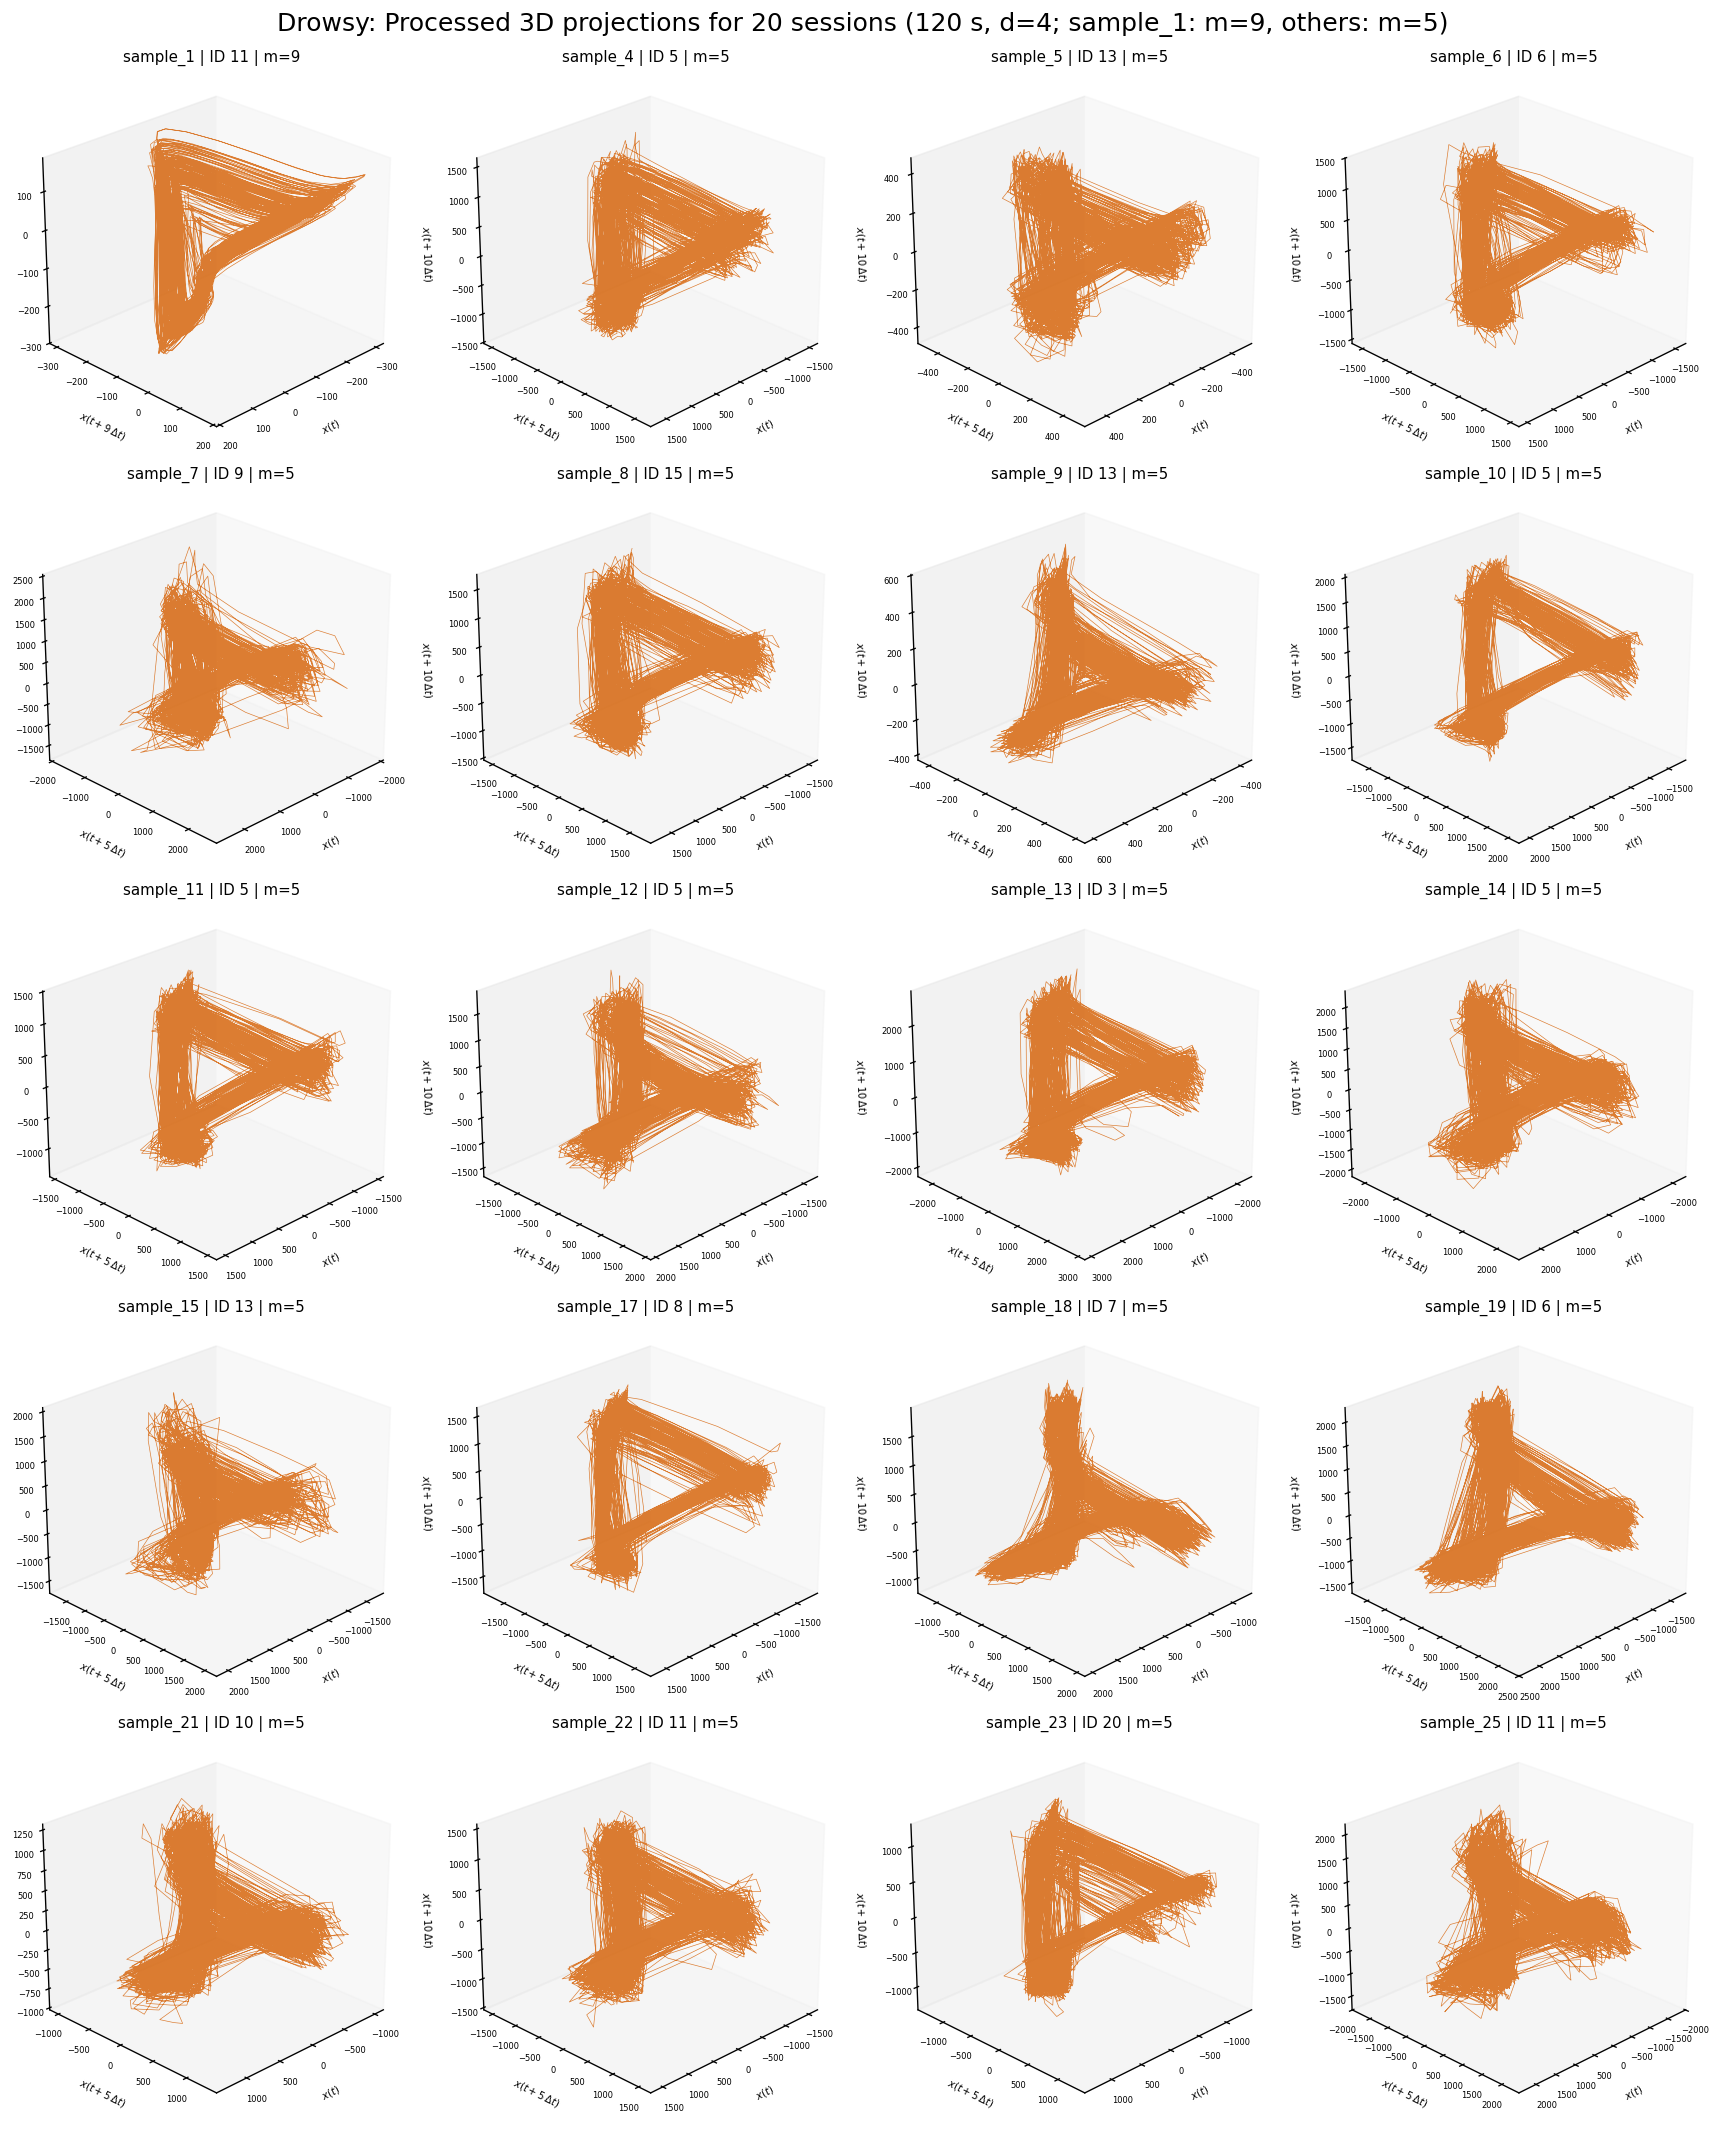

Logged 20 Drowsy Processed 3D plots for 120 s windows (sample_1: m=9; others: m=5).


In [14]:
drowsy_120_3d_figure = plot_processed_3d_grid(
    session_phases_120,
    session_window_ids_120,
    label=1,
    window_size=120,
)
assert len(session_phases_120[1]) == 20
print(
    "Logged 20 Drowsy Processed 3D plots for 120 s windows "
    "(sample_1: m=9; others: m=5)."
)

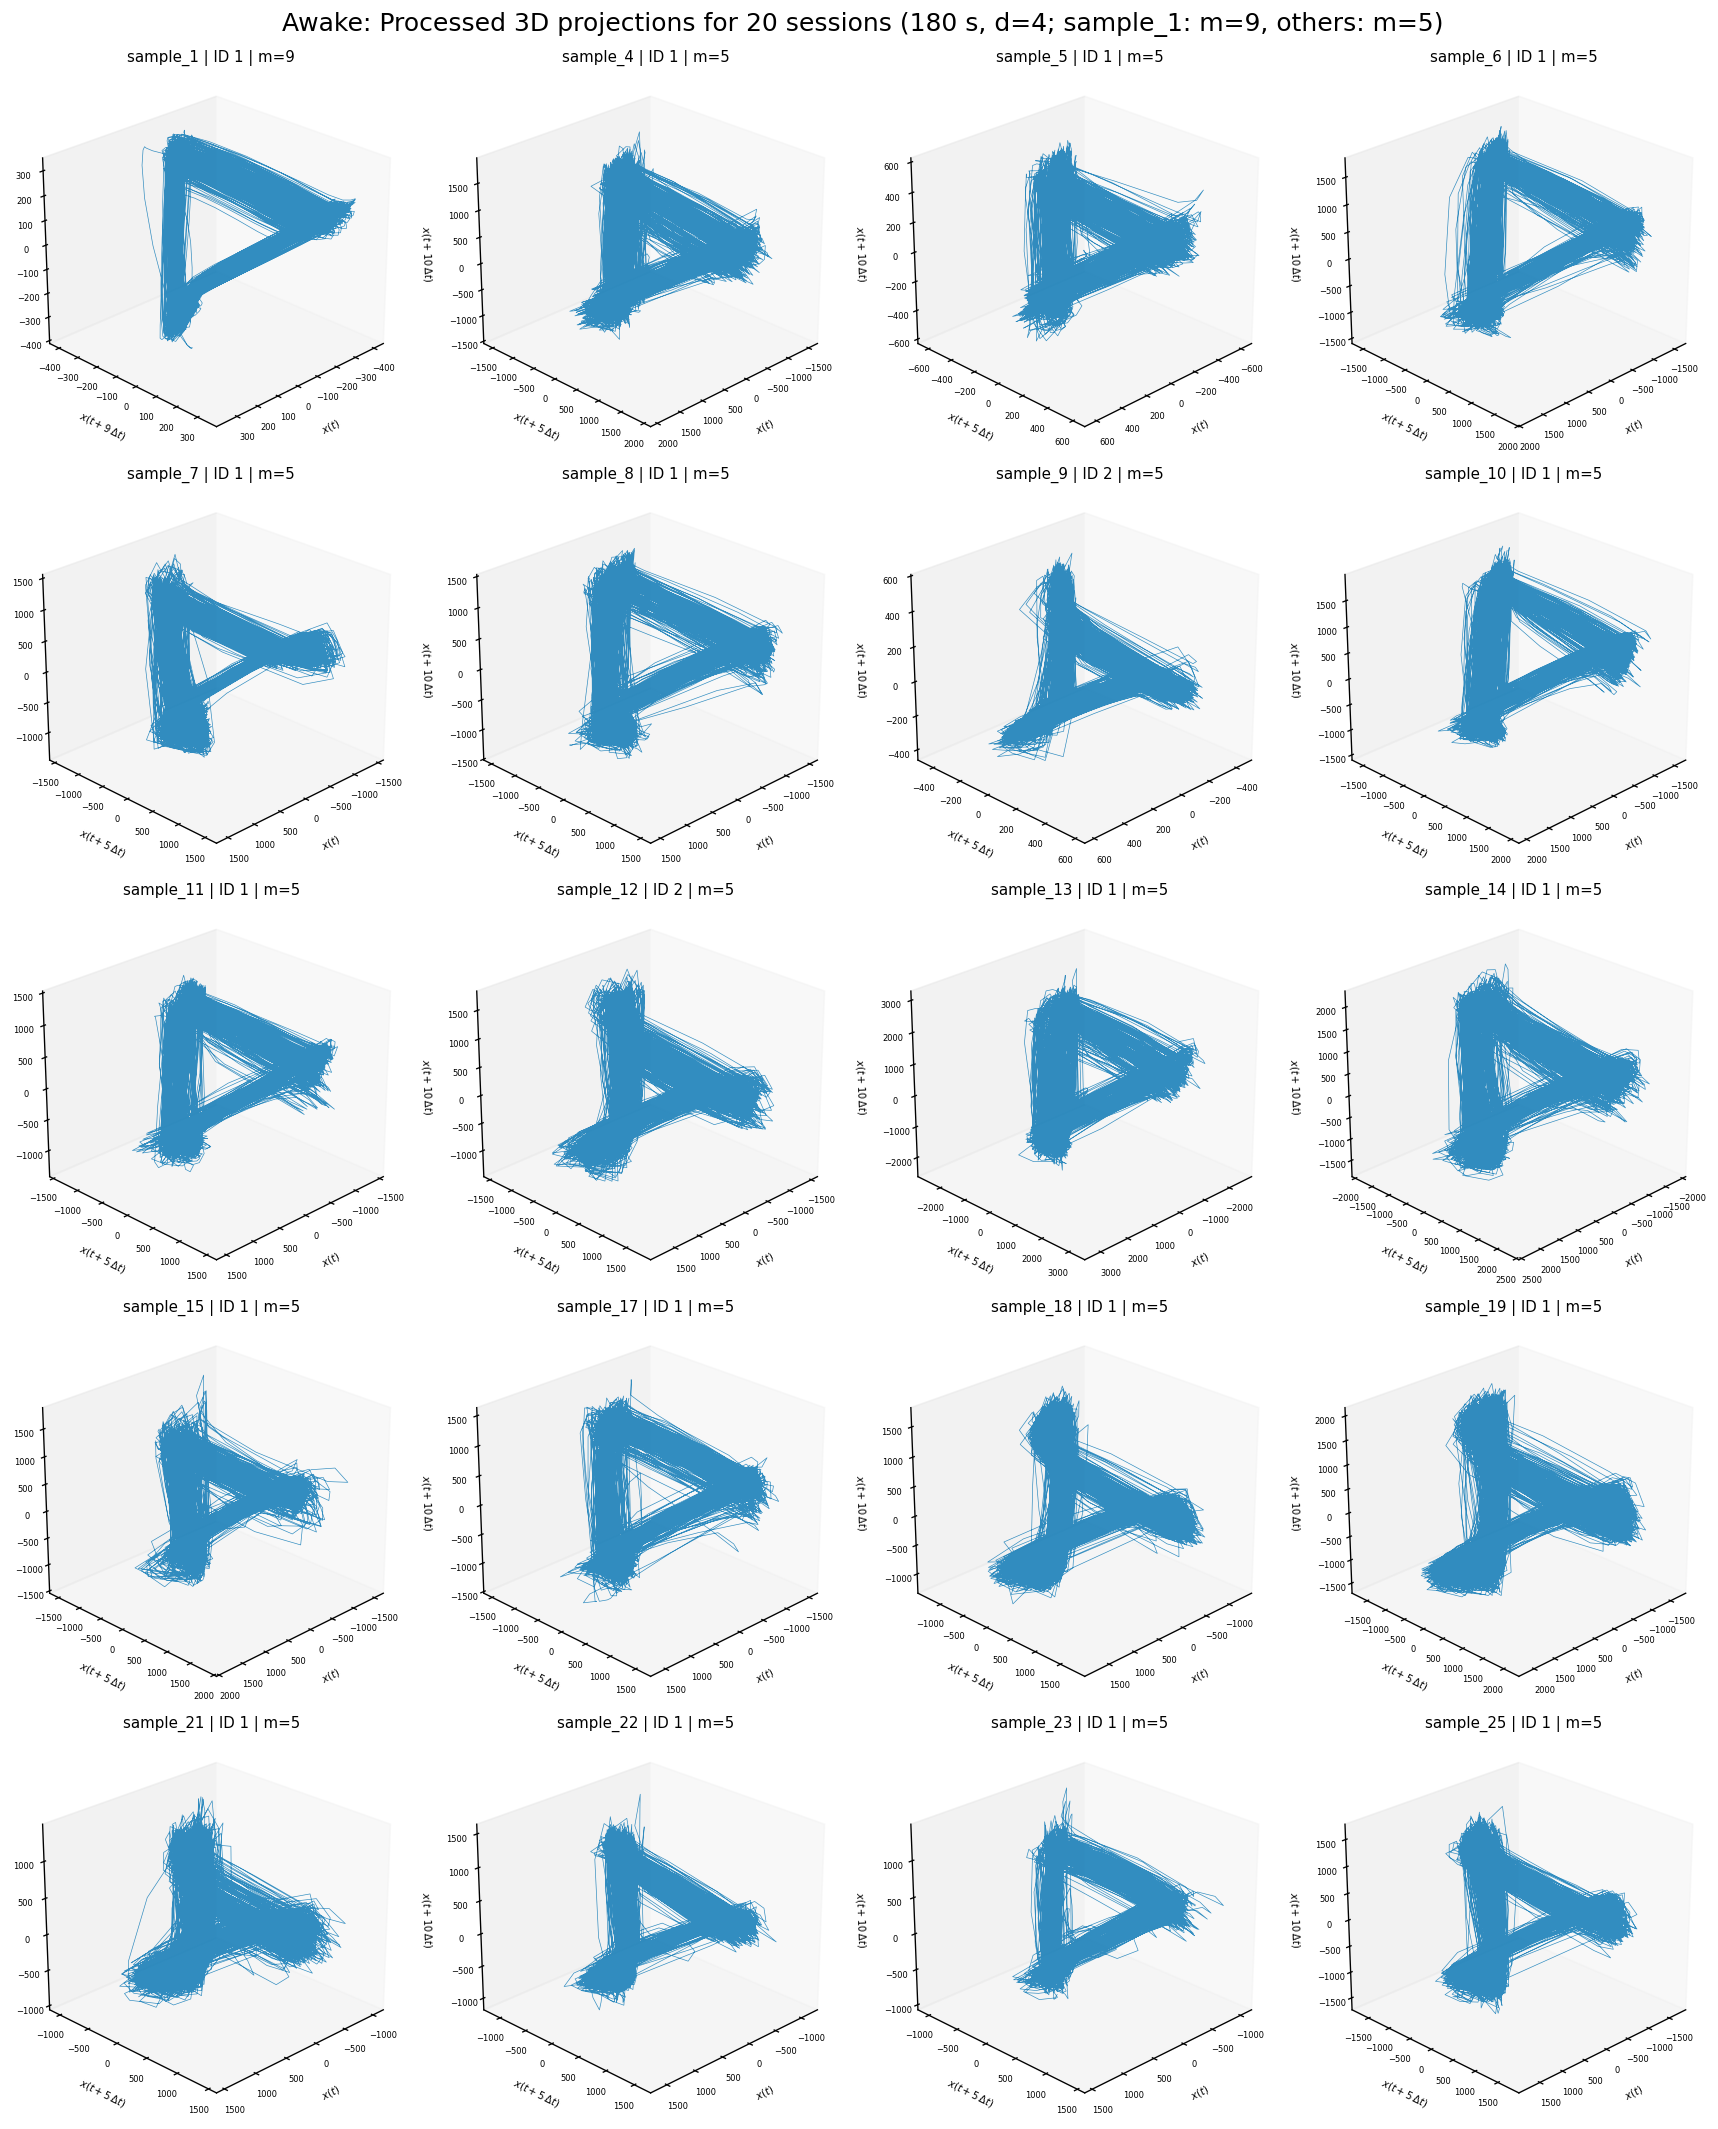

Logged 20 Awake Processed 3D plots for 180 s windows (sample_1: m=9; others: m=5).


In [15]:
session_phases_180, session_window_ids_180 = (
    load_processed_session_phases(180)
)
awake_180_3d_figure = plot_processed_3d_grid(
    session_phases_180,
    session_window_ids_180,
    label=0,
    window_size=180,
)
assert len(session_phases_180[0]) == 20
print(
    "Logged 20 Awake Processed 3D plots for 180 s windows "
    "(sample_1: m=9; others: m=5)."
)

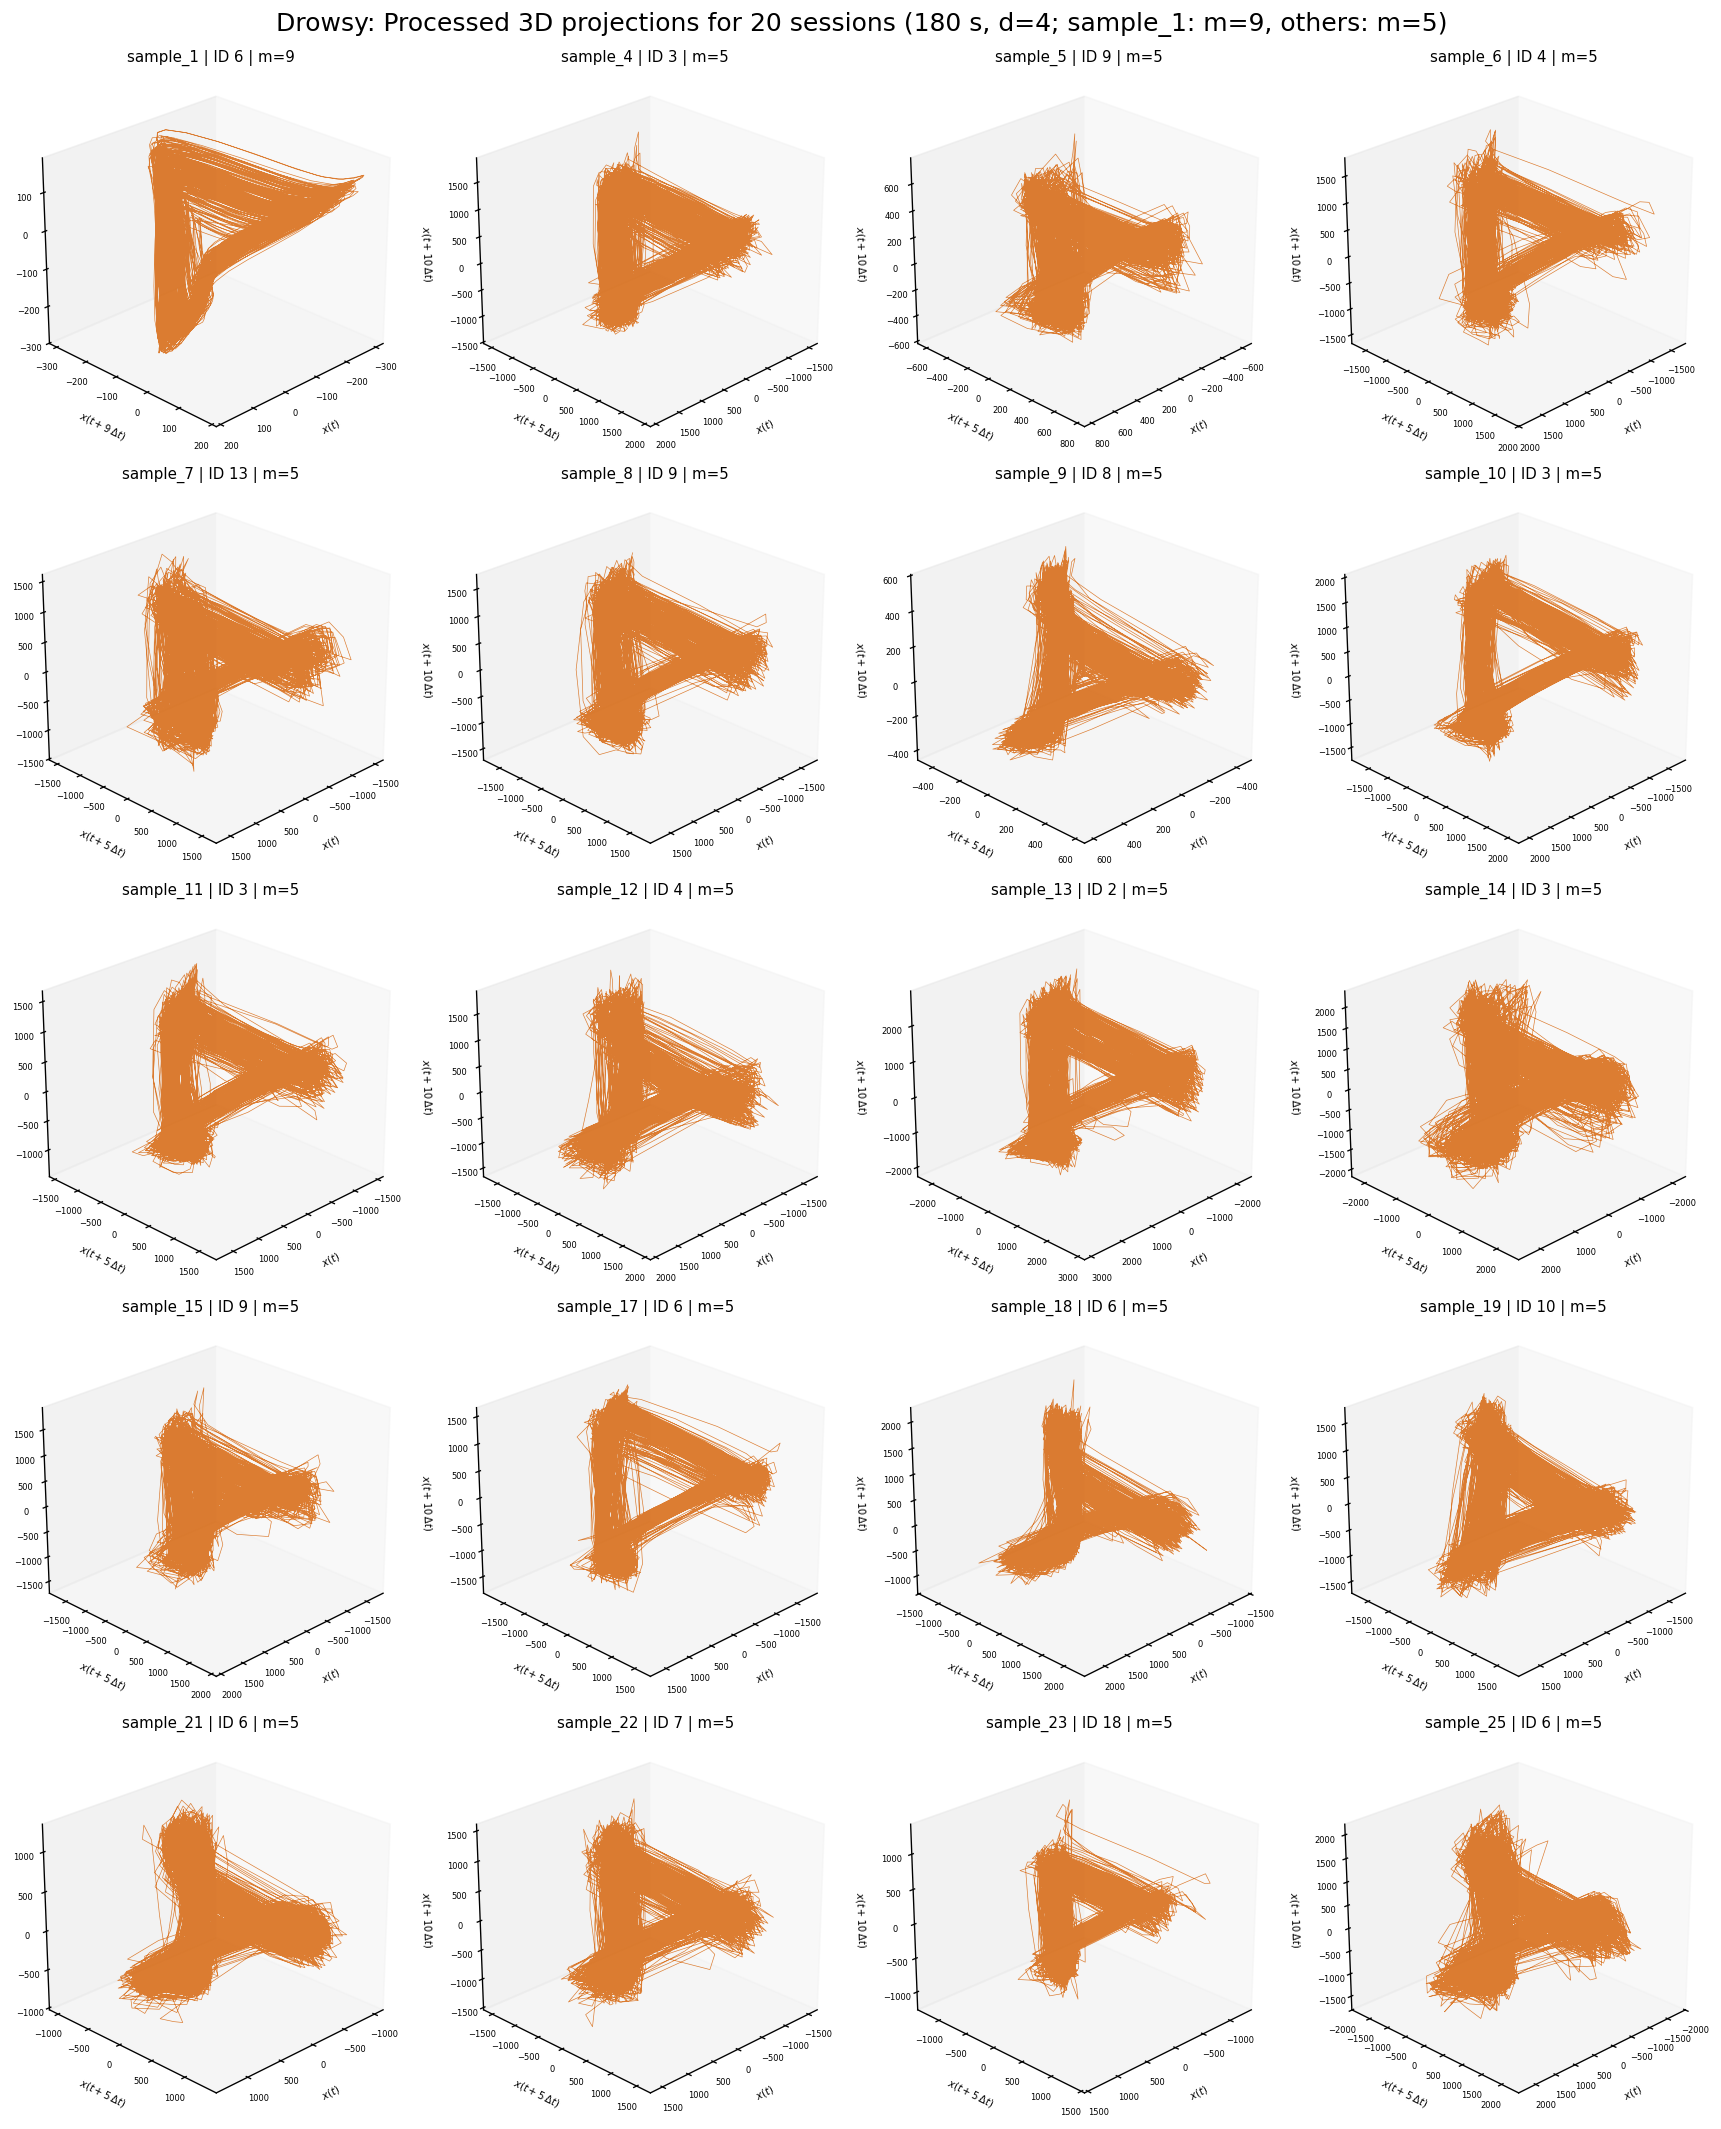

Logged 20 Drowsy Processed 3D plots for 180 s windows (sample_1: m=9; others: m=5).


In [16]:
drowsy_180_3d_figure = plot_processed_3d_grid(
    session_phases_180,
    session_window_ids_180,
    label=1,
    window_size=180,
)
assert len(session_phases_180[1]) == 20
print(
    "Logged 20 Drowsy Processed 3D plots for 180 s windows "
    "(sample_1: m=9; others: m=5)."
)

# Nhận xét sơ bộ về Phase-Space

Phase-space được trực quan hóa từ **một window đại diện cho mỗi session** ở hai trạng thái Awake và Drowsy.

Nhìn chung, cả hai trạng thái đều cho thấy cấu trúc trajectory có tổ chức, không hoàn toàn ngẫu nhiên. Ở một số session, Drowsy có xu hướng phân tán, dày hoặc biến dạng hình học hơn Awake, gợi ý khả năng tồn tại thay đổi phụ thuộc trạng thái trong tổ chức động lực học phi tuyến.

Kết quả này hiện chỉ mang tính **thăm dò trực quan**. Kết luận chính thức cần dựa trên toàn bộ window hợp lệ, aggregate theo session và các metric NTSA định lượng.